# 1 · Demand Patterns and Forecast Comparison

<a href="https://colab.research.google.com/github/FH-Prevail/jku_course/blob/main/notebooks/1_see_and_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

If the button does not open, use this link, or copy it into the browser: <a href="https://colab.research.google.com/github/FH-Prevail/jku_course/blob/main/notebooks/1_see_and_forecast.ipynb" target="_parent">https://colab.research.google.com/github/FH-Prevail/jku_course/blob/main/notebooks/1_see_and_forecast.ipynb</a>

Or in Colab: **File, Open notebook, GitHub**, type `FH-Prevail/jku_course` and choose the notebook.

*UE Digital Analytics im Handel · JKU Linz · 03.10.2026 · Sina Mirshahi, Logistikum*

Choose **Copy to Drive** (File, Save a copy in Drive), then **Runtime → Run all**. Work in pairs. You do not write code: read the tables and use the controls.

The first cell fetches the course data, the precomputed forecasts and the display helpers from the course repository, github.com/FH-Prevail/jku_course. It does not train a model, and it takes a few seconds. The cell can stay collapsed.

**If a control is missing:** use the static example directly above it. If you edited a cell by accident, Undo, then run it again; otherwise reopen a fresh copy from the repository. Restarting does not undo edits.

**Optional Gemini help:** select an output and ask “Explain this table in plain English. Separate what it shows from what it does not prove.” Check the answer against the numbers. If Gemini is unavailable, ask your partner or lecturer. Use only the synthetic course data.


In [1]:
#@title Start here: run this cell once. It fetches the course data from GitHub. Nothing to edit.
import os, sys, pathlib, shutil, urllib.request, importlib, importlib.util, subprocess
required = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "scipy": "scipy", "ipywidgets": "ipywidgets"}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
SOURCE = os.environ.get("T2_SOURCE") or "https://raw.githubusercontent.com/FH-Prevail/jku_course/main"
FILES = ['src/classroom.py', 'data/classroom/results.json', 'data/classroom/products.csv', 'data/classroom/demand.csv', 'data/classroom/comparisons.csv', 'data/classroom/inventory.csv']
folder = pathlib.Path("t2_classroom")
folder.mkdir(exist_ok=True)
try:
    for f in FILES:
        target = folder / pathlib.Path(f).name
        if SOURCE.startswith("http"):
            urllib.request.urlretrieve(f"{SOURCE}/{f}", target)
        else:
            shutil.copy(pathlib.Path(SOURCE) / f, target)
except Exception as e:
    raise SystemExit(f"Could not fetch the course files ({e}). Check the internet connection, then Runtime > Run all again.")
sys.path.insert(0, str(folder.resolve()))
get_ipython().run_line_magic("matplotlib", "inline")
import classroom as lesson
importlib.reload(lesson)
lesson.load(folder)
print("Ready. The course data is loaded.")
print("The forecasts were computed in advance, using only what was known at each forecast date.")


Ready. The course data is loaded.
The forecasts were computed in advance, using only what was known at each forecast date.


## 1. Read the demand

The retailer sells 40 products through two channels, store and online: 80 series of weekly sales. The data is synthetic, built to look like a real retailer's numbers.

Read the channel picture. Is one channel growing? Do you see a recurring busy season?

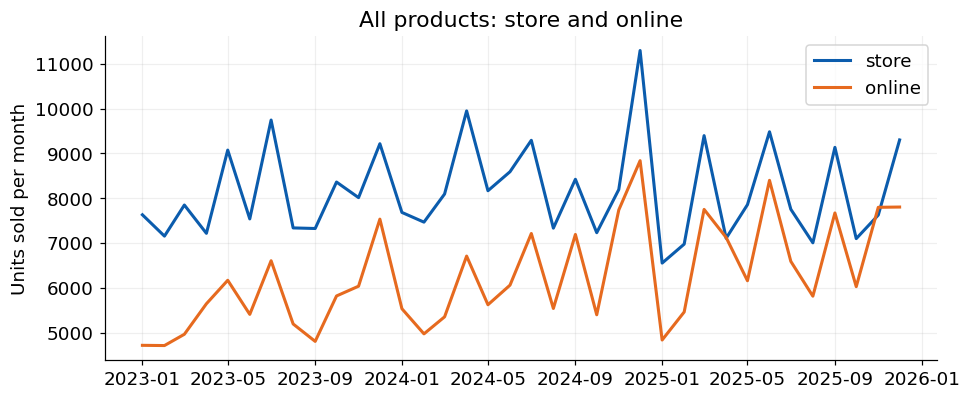

channel,Online units,Store units
Year,,
2023,67585,96444
2024,76149,101707
2025,81414,95272


In [2]:
lesson.totals()

**What to see.** Online totals grow from 2023 to 2025. Store totals fluctuate rather than growing each year. A monthly total also depends on how many weekly observations fall in that month.

Four demand patterns are useful descriptions, not guarantees of forecast accuracy: **smooth** means regular sales and fairly regular amounts; **erratic** means frequent sales with variable amounts; **intermittent** means many weeks without sales; **lumpy** adds variable amounts to those gaps.

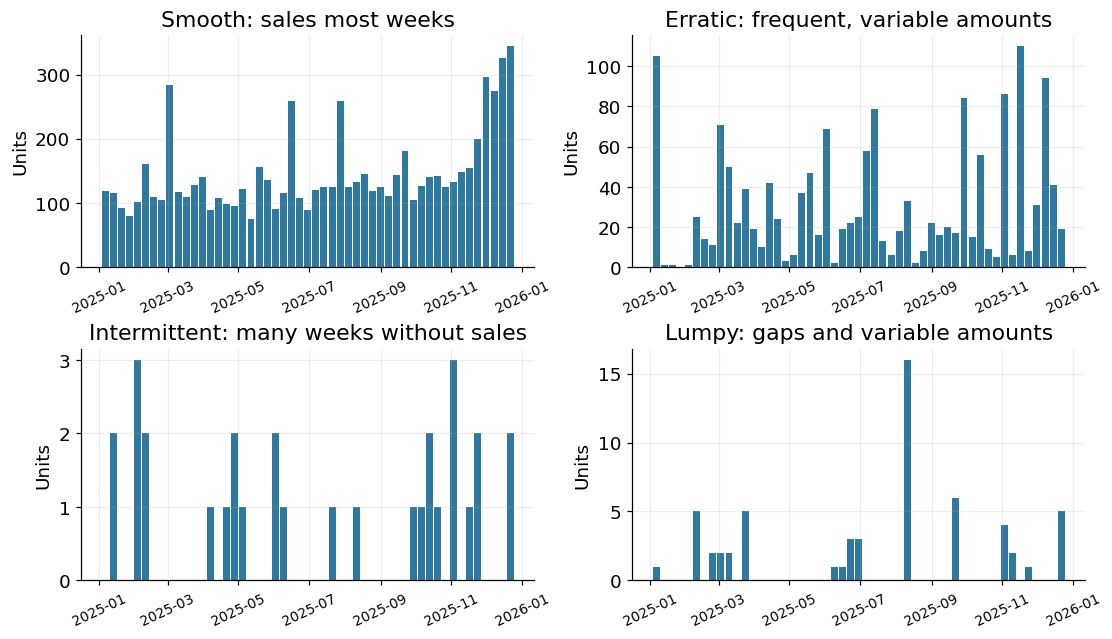

In [3]:
lesson.pattern_examples()

Two numbers place every product on one picture. **ADI** (average demand interval) is the average number of weeks between sales: 1 means a sale every week. **CV²** (squared coefficient of variation) says how irregular the amounts are from one sale to the next. The dashed lines are the usual limits from the literature, 1.32 and 0.49; they are a convention, not a law.

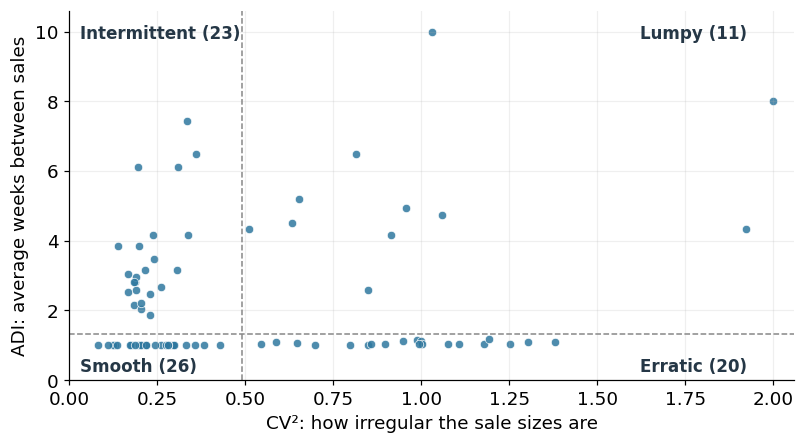

Each dot is one product in one channel, classified on 2023 and 2024. Values beyond the edge are drawn on the edge.
ADI: the average number of weeks between sales (1 = a sale every week). CV²: how irregular the amounts are from one sale to the next.


In [4]:
lesson.pattern_map()

## 2. Compare four approaches

- **Repeat last year**, also called seasonal naive: reuse sales from 52 weeks earlier.
- **Simple exponential smoothing (SES)**: a weighted average that gives more weight to recent sales; it forecasts one constant level for all weeks ahead.
- **Prophet**, a local model from Meta: one model per product and channel that adds up a trend, a yearly season and the effect of the planned discount.
- **LightGBM in global mode**: one LightGBM model learns from all products and channels, using past sales and planned prices, promotions and calendar information. (LightGBM can also be trained one series at a time, in local mode; here it runs in global mode.)

We forecast the same four weeks with each method and then reveal actual sales. An **average miss** is the average absolute difference in units. **Total miss as a percentage of demand** adds up those absolute misses and divides by total actual demand. **Bias** is the average forecast minus actual: positive means too high, negative means too low.

First look at the Christmas example. Do not choose a winner from the shape alone; read its errors too.

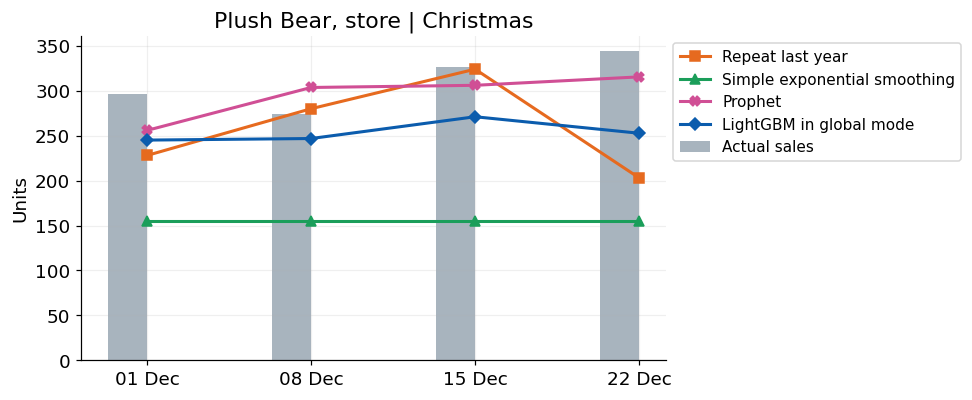

Forecast made after 2025-11-24; all four weeks forecast together.


,"Average miss, units","Total miss, % of demand","Average bias, units"
Method,,,
Repeat last year,54.2,17.5 %,-51.2
Simple exponential smoothing,154.9,50.0 %,-154.9
Prophet,29.6,9.5 %,-14.7
LightGBM in global mode,56.1,18.1 %,-56.1


In this window, Prophet has the smallest average miss. This is evidence for this product and window only.
Bias is forecast minus actual: positive means too high; negative means too low.


In [5]:
lesson.compare('Plush Bear, store', 'Christmas')

**What to see.** The printed sentence names the method with the smallest miss in this window. The bias column adds direction; the same method need not win in another season or for another product.

**Try it using the dropdowns.** Change Window to Summer. Then select Garden Hose, store. Compare that product in Summer and Christmas. Change Plush Bear from store to online to investigate a channel difference.

In [6]:
forecast_controls = lesson.forecast_widget()

The interactive controls appear when you run this notebook in Colab. Until then, use the static example above.


## 3. Your first recommendation

Discuss these questions with your partner:

1. Which product and window did you choose?
2. Which method has the smallest miss, and is its bias positive or negative?
3. Does your choice change with the season or channel?

Complete this sentence in your notes: **“For ___ in ___, I would start with ___ because ___. Before ordering, I would also check ___.”**

Stop here for the first exercise. The following sections support the evaluation discussion after the break.

## 4. Check more than one window

A **backtest** replays past forecast decisions using only information available then. Here every method is tested at 13 dates, predicting the next four weeks each time; the test weeks run from 30 December 2024 to 22 December 2025.

**WAPE**, weighted absolute percentage error, is total absolute miss divided by total actual demand. **Percentage bias** is total signed error divided by total demand; earlier we expressed bias in units instead. Both definitions use forecast minus actual for the sign.

In [7]:
lesson.backtest()

13 test dates; four weeks ahead each; all 80 series. The same weeks and products for every method.
The four methods of the window comparison come first; four more local methods from the slides were scored the same way.
Flagged stockout observations are excluded from scoring because their demand is unknown.


,WAPE: total miss / total demand,Bias: net error / total demand
Method,,
Repeat last year,43.8 %,-2.7 %
Simple exponential smoothing,34.9 %,-0.9 %
Prophet,27.1 %,+0.3 %
LightGBM in global mode,25.1 %,-3.1 %
Holt-Winters,39.0 %,-1.0 %
Croston SBA,34.9 %,-4.9 %
TSB,36.1 %,+0.0 %
Moving average,37.5 %,+0.2 %


**What to see.** The table compares all 80 series on the same dates; the four extra rows are the further local methods from the slides (Holt-Winters, Croston SBA, TSB, a moving average), scored the same way. Large sellers have more influence on these aggregate percentages, so the best assortment result does not promise the best result for your product. These results were computed in advance; LightGBM in global mode was retrained at each test date.

## 5. A forecast can be right most weeks and still miss all sales

**MAPE**, mean absolute percentage error, computes a percentage miss for each week before averaging. A week with zero actual demand makes that division undefined.

In [8]:
lesson.zeros_demo()

Teaching example, not an extracted course product.


,Week,Actual units,Forecast units
0,1,0,0.0
1,2,0,0.0
2,3,0,0.0
3,4,4,0.0


Three weeks exactly right, but all four units of demand missed.
MAPE is undefined because actual demand is zero in three weeks. WAPE is 100 %.
Do not choose a stock policy by counting the weeks a forecast gets right.


**What to see.** The zero forecast matches three weeks exactly but misses the only sale. Counting correct weeks is not enough to judge an order policy; carry this question into notebook 2: how much stock would you need?

**Evidence note.** Four observations in the source data are flagged as censored sales: the shelf was empty, so demand is unknown. For training, these are replaced with the preceding four weeks’ mean using only past information; flagged test rows are excluded from forecast scoring. The README of the `data` folder in the course repository describes the data in full.